# 1: imports & config

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2: Load the Data

In [3]:
import pandas as pd

path = "/content/drive/MyDrive/data/togo-dapaong_qc.csv"
df = pd.read_csv(path, parse_dates=["Timestamp"])
df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Timestamp      525600 non-null  datetime64[ns]
 1   GHI            525600 non-null  float64       
 2   DNI            525600 non-null  float64       
 3   DHI            525600 non-null  float64       
 4   ModA           525600 non-null  float64       
 5   ModB           525600 non-null  float64       
 6   Tamb           525600 non-null  float64       
 7   RH             525600 non-null  float64       
 8   WS             525600 non-null  float64       
 9   WSgust         525600 non-null  float64       
 10  WSstdev        525600 non-null  float64       
 11  WD             525600 non-null  float64       
 12  WDstdev        525600 non-null  float64       
 13  BP             525600 non-null  int64         
 14  Cleaning       525600 non-null  int64         
 15  

,0
Timestamp,0
GHI,0
DNI,0
DHI,0
ModA,0
ModB,0
Tamb,0
RH,0
WS,0
WSgust,0


#3: Data Profiling & Missing Value Report

In [4]:
# List any column with >5% nulls
print("\n--- Columns with >5% Missing Data ---")
missing_pct = df.isna().mean()
print(missing_pct[missing_pct > 0.05])


--- Columns with >5% Missing Data ---
Comments    1.0
dtype: float64


# 4.Outlier Detection & Basic Cleaning
 We will compute Z-scores for key sensor readings and wind data to identify and remove extreme outliers.

In [5]:

from scipy import stats

cols = ["GHI","DNI","DHI","ModA","ModB","WS","WSgust"]
df_clean = df.copy()
for c in cols:
    df_clean[c + "_z"] = stats.zscore(df_clean[c].fillna(df_clean[c].median()))
# flag
df_clean['outlier_flag'] = df_clean[[c+"_z" for c in cols]].abs().max(axis=1) > 3

# Option: drop extreme
df_clean = df_clean[~df_clean['outlier_flag']]

# Impute remaining missing in key columns with median
for c in cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

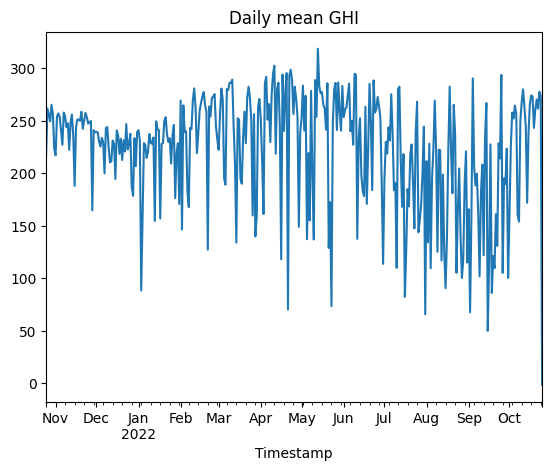

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
df_clean.set_index("Timestamp", inplace=True)
df_clean["GHI"].resample("D").mean().plot(title="Daily mean GHI")
plt.show()

In [7]:
grouped = df_clean.groupby("Cleaning")[["ModA","ModB"]].mean().reset_index()
display(grouped)

,Cleaning,ModA,ModB
0,0,219.217037,212.861920
1,1,528.864835,527.268498


# Visualization using heatmap

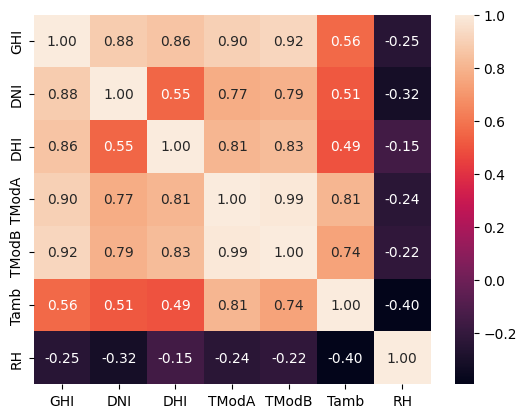

In [8]:
cols = ["GHI","DNI","DHI","TModA","TModB","Tamb","RH"]
sns.heatmap(df_clean[cols].corr(), annot=True, fmt=".2f")
plt.show()

# Visualization using windrose

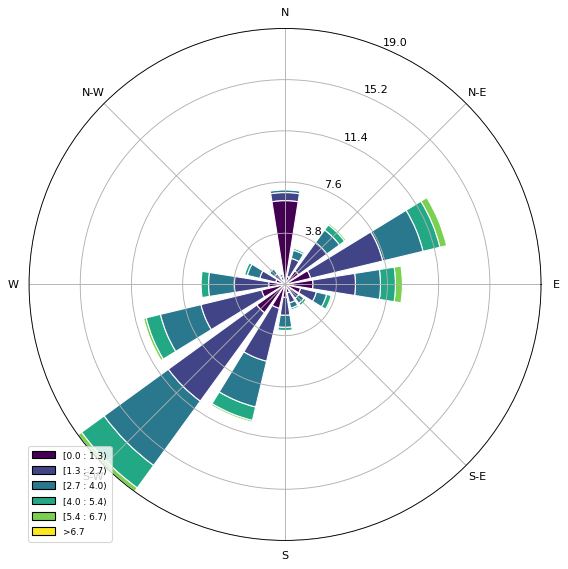

In [11]:
from windrose import WindroseAxes
ax = WindroseAxes.from_ax()
ax.bar(df_clean['WD'], df_clean['WS'], normed=True, opening=0.8, edgecolor='white')
ax.set_legend()
plt.show()

In [12]:
df_clean.reset_index().to_csv("/content/drive/MyDrive/data/clean_togo-dapaong_qc.csv", index=False)
